# Plot Retrieval Count (Cleaned)

This notebook is cleaned and ordered to follow figure panels **m → s**.


## 1) Load Inputs


In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


dct_result = dict()

with open("OpenAI/OpenAI_same_question_response_with_id.pkl", "rb") as f:
    OpenAI_same_question_response = pickle.load(f)

with open("Grok/Grok_same_question_response_with_id.pkl", "rb") as f:
    Grok_same_question_response = pickle.load(f)

with open("Gemini/Gemini_same_question_response_with_id.pkl", "rb") as f:
    Gemini_same_question_response = pickle.load(f)

with open("Llama/Llama_same_question_response_with_id.pkl", "rb") as f:
    Llama_same_question_response = pickle.load(f)

with open("OpenTargets/OpenTargets_same_question_response_with_id.pkl", "rb") as f:
    Opentarget_same_question_response = pickle.load(f)

with open("biochatter/Biochatter_same_question_response_with_id.pkl", "rb") as f:
    Biochatter_same_question_response = pickle.load(f)

with open("ttd/TTD_same_question_response_with_id.pkl", "rb") as f:
    TTD_same_question_response = pickle.load(f)

with open("ctd/CTD_same_question_response_with_id.pkl", "rb") as f:
    CTD_same_question_response = pickle.load(f)

with open("hcdt/HCDT_same_question_response_with_id.pkl", "rb") as f:
    HCDT_same_question_response = pickle.load(f)





## 2) Build Unified Result Dictionary


In [2]:
# for model in ['llama-3.3-70b-versatile', 'gpt-5-nano', 'grok-4-1-fast-non-reasoning-latest', "gemini-2.5-flash-lite", "OpenTarget", "BioChatter"]:
for model in ['llama-3.3-70b-versatile', 'grok-4-1-fast-non-reasoning-latest', 'gpt-5-nano', "gemini-2.5-flash-lite", "BioChatter", "OpenTargets", "ttd", "ctd", "hcdt"]:

    
    if model=="llama-3.3-70b-versatile":
        dct_result[model] = Llama_same_question_response[model]

    if model=="gpt-5-nano":
        dct_result[model] = OpenAI_same_question_response[model]

    if model=='grok-4-1-fast-non-reasoning-latest':
        dct_result[model] = Grok_same_question_response[model]

    if model=="gemini-2.5-flash-lite":
        dct_result[model] = Gemini_same_question_response[model]

    if model=="OpenTargets":
        dct_result[model] = Opentarget_same_question_response[model]

    if model=="BioChatter":
        dct_result[model] = Biochatter_same_question_response[model]

    if model=="ttd":
        dct_result[model] = TTD_same_question_response[model]

    
    if model=="ctd":
        dct_result[model] = CTD_same_question_response[model]

    if model=="hcdt":
        dct_result[model] = HCDT_same_question_response[model]

## 3) Build Run-Level Tables


In [3]:
records = []

for model, queries in dct_result.items():           # model level
    for query, runs in queries.items():             # query level
        for run_id, payload in runs.items():        # run level
            records.append({
                "model": model,
                "query": query,
                "run": int(run_id),
                "rows": int(payload.get("rows", 0)),
                "latency": payload.get("latency", 0)
            })

df = pd.DataFrame(records)


In [4]:
heat_df_rows = (
    df
    .groupby(["model", "run"])["rows"]
    .median()          # robust to explosions
    .unstack(fill_value=0)
)


heat_df_latency = (
    df
    .groupby(["model", "run"])["latency"]
    .median()          # robust to explosions
    .unstack(fill_value=0)
)


## Panel m-n: Median Rows and latency Heatmap


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

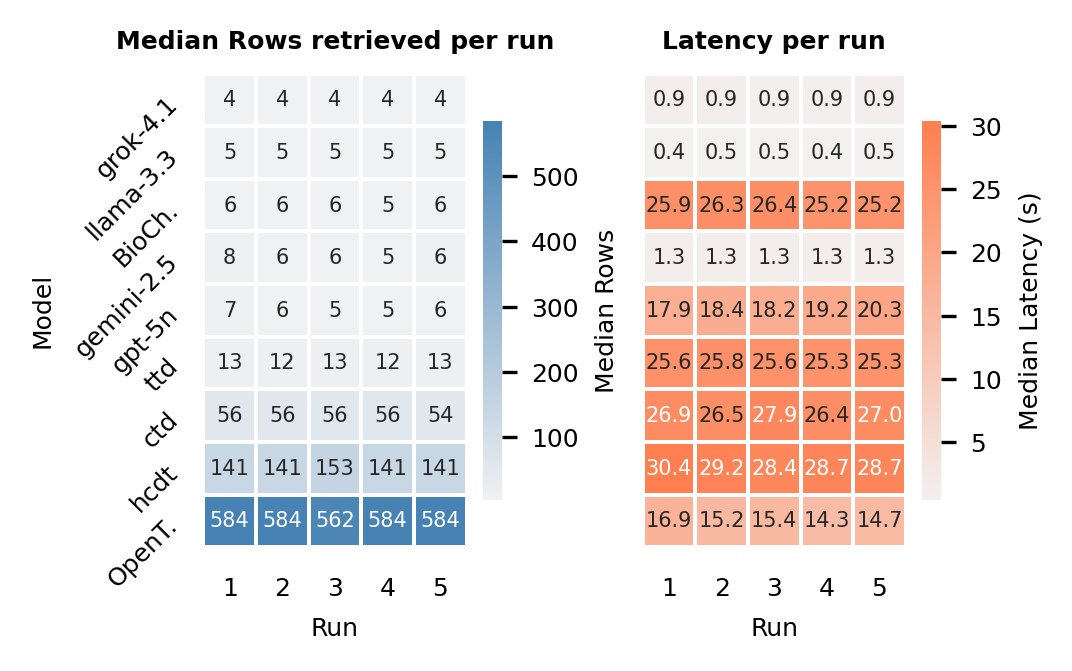

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# =============================================================================
# 1. Strict Arial 6pt Theme & Vector PDF Export
# =============================================================================
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

# Set all default font sizes to 6
mpl.rcParams['font.size'] = 6
mpl.rcParams['axes.titlesize'] = 6
mpl.rcParams['axes.labelsize'] = 6
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6
mpl.rcParams['legend.fontsize'] = 6

# =============================================================================
# 2. Sort Data by Lowest -> Highest Median Rows
# =============================================================================
# Calculate the overall median across the runs for each model
overall_row_medians = heat_df_rows.median(axis=1)

# Sort the index from lowest to highest median
sorted_models = overall_row_medians.sort_values(ascending=True).index

# Apply this sorted order to BOTH dataframes
heat_df_rows = heat_df_rows.loc[sorted_models]
heat_df_latency = heat_df_latency.loc[sorted_models]

# =============================================================================
# 3. Shorten Model Names (Y-axis labels)
# =============================================================================
# Map long names to shorter, cleaner versions
name_mapping = {
    "grok-4-1-fast-non-reasoning-latest": "grok-4.1",
    "llama-3.3-70b-versatile": "llama-3.3",
    "gemini-2.5-flash-lite": "gemini-2.5",
    "gpt-5-nano": "gpt-5n",
    "OpenTargets": "OpenT.",
    "BioChatter": "BioCh."
    # ctd, ttd, and hcdt are already short, so we leave them as is
}

heat_df_rows = heat_df_rows.rename(index=name_mapping)
heat_df_latency = heat_df_latency.rename(index=name_mapping)

# =============================================================================
# 4. Define Soft, Smooth Custom Colormaps
# =============================================================================
cmap_rows = sns.light_palette("steelblue", as_cmap=True)
cmap_latency = sns.light_palette("coral", as_cmap=True)

# =============================================================================
# 5. Setup Figure (90 x 60 mm)
# =============================================================================
# Conversion: 1 inch = 25.4 mm
mm_to_in = 1 / 25.4
fig_width = 90 * mm_to_in
fig_height = 60 * mm_to_in

fig, ax = plt.subplots(
    1, 2,
    figsize=(fig_width, fig_height),
    dpi=300,
    sharey=True
)

# =============================================================================
# 6. Heatmap 1: Row count (Square boxes)
# =============================================================================
sns.heatmap(
    heat_df_rows,
    annot=True,
    fmt=".0f",
    cmap=cmap_rows,
    linewidths=0.5,
    linecolor='white',
    square=True,             
    annot_kws={"size": 5},   
    cbar_kws={
        "label": "Median Rows",
        "shrink": 0.8
    },
    ax=ax[0]
)

ax[0].set_title("Median Rows retrieved per run", pad=6, fontweight="bold")
ax[0].set_xlabel("Run", labelpad=4)
ax[0].set_ylabel("Model", labelpad=4)
ax[0].tick_params(left=False, bottom=False)

# Rotate the y-axis labels 45 degrees and align them cleanly
plt.setp(ax[0].get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# =============================================================================
# 7. Heatmap 2: Latency (Square boxes)
# =============================================================================
sns.heatmap(
    heat_df_latency,
    annot=True,
    fmt=".1f",
    cmap=cmap_latency,
    linewidths=0.5,
    linecolor='white',
    square=True,             
    annot_kws={"size": 5},   
    cbar_kws={
        "label": "Median Latency (s)",
        "shrink": 0.8
    },
    ax=ax[1]
)

ax[1].set_title("Latency per run", pad=6, fontweight="bold")
ax[1].set_xlabel("Run", labelpad=4)
ax[1].set_ylabel("") 
ax[1].tick_params(left=False, bottom=False)

# =============================================================================
# 8. Suptitle & Layout
# =============================================================================
# fig.suptitle(
#     "Stability of model responses across 70 runs",
#     fontsize=6,
#     fontweight="bold",
#     y=0.98
# )

# Use tight_layout but leave room for the suptitle
plt.tight_layout(rect=[0, 0, 1, 0.93])

# =============================================================================
# 9. Export as Editable Vector PDF
# =============================================================================
plt.savefig(
    "soft_sorted_heatmaps_90x60_square_angled.pdf", 
    format="pdf", 
    bbox_inches="tight", 
    transparent=True
)

plt.show()

## Panel o: Jaccard Stability Boxplot


/tmp/ipykernel_3814792/1075727803.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3814792/1075727803.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following 

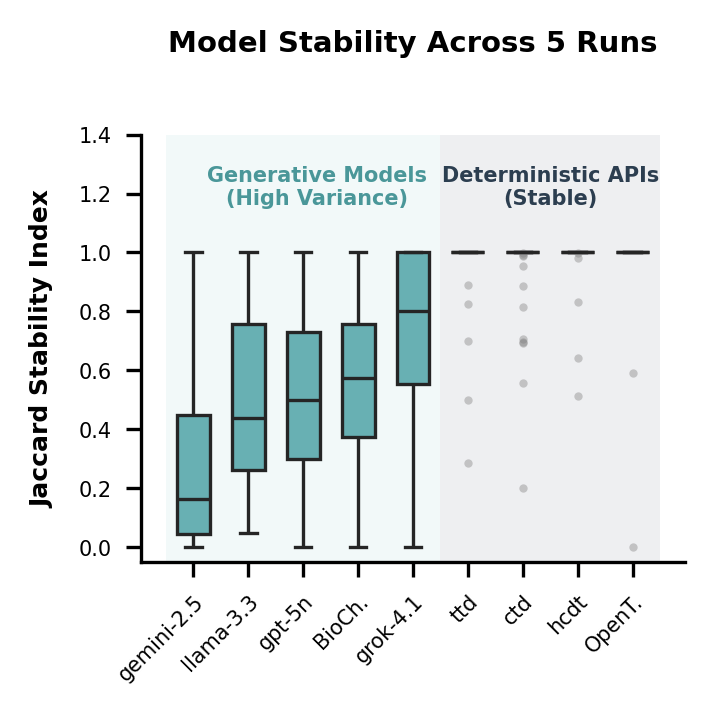

Plot saved as jaccard_boxplot_60x60.pdf


In [6]:
import pandas as pd

dct_jaccard = {}

for model, queries in dct_result.items():
    dct_jaccard[model] = {}

    for question, runs in queries.items():
        run_sets = []

        for _, payload in runs.items():
            df = payload.get("dataframe_id")

            if not isinstance(df, pd.DataFrame) or df.empty:
                continue

            try:
                row_set = set()
                id_cols = sorted([c for c in df.columns if c.endswith("_id")])

                if not id_cols:
                    continue

                for row in df[id_cols].itertuples(index=False, name=None):
                    cleaned = tuple(
                        str(v).strip().lower()
                        for v in row
                        if v is not None and not pd.isna(v)
                    )
                    if cleaned:
                        row_set.add(cleaned)

                if row_set:
                    run_sets.append(row_set)

            except Exception:
                continue

        if len(run_sets) < 2:
            dct_jaccard[model][question] = None
            continue

        intersection = set.intersection(*run_sets)
        union = set.union(*run_sets)
        dct_jaccard[model][question] = len(intersection) / len(union) if union else 0.0

records = []
for model, qdict in dct_jaccard.items():
    for question, jac in qdict.items():
        if jac is None:
            continue
        records.append({"model": model, "query": question, "jaccard": jac})

df_jaccard = pd.DataFrame(records)


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# =============================================================================
# 1. Apply Short Names to DataFrame
# =============================================================================
name_mapping = {
    "grok-4-1-fast-non-reasoning-latest": "grok-4.1",
    "llama-3.3-70b-versatile": "llama-3.3",
    "gemini-2.5-flash-lite": "gemini-2.5",
    "gpt-5-nano": "gpt-5n",
    "OpenTargets": "OpenT.",
    "BioChatter": "BioCh.",
    "ctd": "ctd",
    "ttd": "ttd",
    "hcdt": "hcdt"
}

df_jaccard["model"] = df_jaccard["model"].replace(name_mapping)

deterministic_apis = ["ttd", "ctd", "hcdt", "OpenT."]

# =============================================================================
# 2. Calculate Medians & Define Custom Sort Order with Tie-Breaker
# =============================================================================
medians = df_jaccard.groupby("model")["jaccard"].median()

tie_breaker = {"ttd": 1, "ctd": 2, "hcdt": 3, "OpenT.": 4}

def sort_key(model_name):
    med = medians[model_name]
    rank = tie_breaker.get(model_name, 99)
    return (med, rank)

order = sorted(medians.index, key=sort_key)

# =============================================================================
# 3. Plotting Configuration (60x60mm, True Vector PDF)
# =============================================================================
# Force True vector text for PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Global font settings scaled for a small 60mm figure
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['font.size'] = 6
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 6
mpl.rcParams['xtick.labelsize'] = 5
mpl.rcParams['ytick.labelsize'] = 5

# Convert 60mm to inches
mm_to_in = 1 / 25.4
fig_size = 60 * mm_to_in

# Create 60x60mm figure
fig, ax = plt.subplots(figsize=(fig_size, fig_size), dpi=300)

# Custom palette
palette = ["#5BBCBF" if m not in deterministic_apis else "#2C3E50" for m in order]

# Plot the boxplot
sns.boxplot(
    data=df_jaccard,
    x="model",
    y="jaccard",
    order=order,
    palette=palette,
    linewidth=0.8,           # Thinner lines for smaller plot
    width=0.6,               
    fliersize=2,             # Smaller outlier points
    flierprops={"marker": "o", "markerfacecolor": "gray", "markeredgecolor": "none", "alpha": 0.4},
    ax=ax
)

# =============================================================================
# 4. Insight Annotations & Zoning
# =============================================================================
api_start_idx = next(i for i, m in enumerate(order) if m in deterministic_apis)

# Soft background rectangles
ax.axvspan(-0.5, api_start_idx - 0.5, color='#5BBCBF', alpha=0.08, lw=0)
ax.axvspan(api_start_idx - 0.5, len(order) - 0.5, color='#2C3E50', alpha=0.08, lw=0)

# Overarching titles for the groups (scaled down to 5pt font)
ax.text(
    (api_start_idx - 0.5) / 2, 1.15, 
    "Generative Models\n(High Variance)", 
    ha='center', va='bottom', fontsize=5, fontweight='bold', color='#4a9799'
)
ax.text(
    api_start_idx - 0.5 + (len(order) - api_start_idx) / 2, 1.15, 
    "Deterministic APIs\n(Stable)", 
    ha='center', va='bottom', fontsize=5, fontweight='bold', color='#2C3E50'
)

# =============================================================================
# 5. Beautification & Formatting
# =============================================================================
ax.set_ylabel("Jaccard Stability Index", fontweight="bold", labelpad=6)
ax.set_xlabel("")  
ax.set_title("Model Stability Across 5 Runs", pad=20, fontweight="bold")

# Expand Y-axis to give the text room in the 60mm square
ax.set_ylim(-0.05, 1.4)

# Removed grid lines per request
# Clean up axes top/right borders
sns.despine(top=True, right=True)

# Rotate X-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

plt.tight_layout()

# Save as true vector PDF
plt.savefig("jaccard_boxplot_60x60.pdf", format='pdf', bbox_inches='tight', transparent=True)

plt.show()
print("Plot saved as jaccard_boxplot_60x60.pdf")


## Panel p: Unresolved Entity Bubble Matrix


/tmp/ipykernel_3814792/3496587511.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().capitalize() for label in ax.get_xticklabels()])
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont

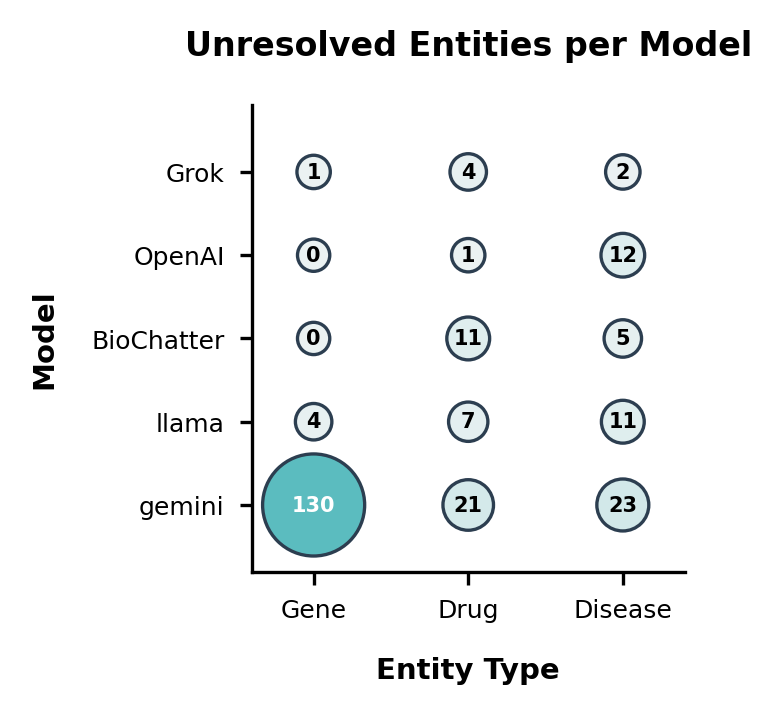

Plot saved as unresolved_entities_proper_axes.pdf


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# =============================================================================
# 1. Data Prep
# =============================================================================
raw_data = {
    "llama": {"gene": 4, "drug": 7, "disease": 11},
    "gemini": {"gene": 130, "drug": 21, "disease": 23},
    "Grok": {"gene": 1, "drug": 4, "disease": 2},
    "OpenAI": {"gene": 0, "drug": 1, "disease": 12},
    "BioChatter": {"gene": 0, "drug": 11, "disease": 5}
}

# Convert to DataFrame and melt for Seaborn
df = pd.DataFrame(raw_data).T
df_melted = df.reset_index().melt(
    id_vars="index", 
    var_name="Entity", 
    value_name="Count"
)
df_melted.rename(columns={"index": "Model"}, inplace=True)

# Sort models by total unresolved entities (lowest to highest) to create a clean visual flow
model_totals = df.sum(axis=1).sort_values(ascending=True)
df_melted["Model"] = pd.Categorical(df_melted["Model"], categories=model_totals.index, ordered=True)

# =============================================================================
# 2. Plotting Configuration (High-End Vector PDF)
# =============================================================================
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['font.size'] = 6
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6

# Convert mm to inches (60x60mm square as requested)
mm_to_in = 1 / 25.4
fig, ax = plt.subplots(figsize=(60 * mm_to_in, 60 * mm_to_in), dpi=300)

# =============================================================================
# 3. Create the Bubble Matrix with your #5BBCBF Theme
# =============================================================================
# Create a custom gradient from white to your specified Cyan/Teal
cyan_cmap = sns.light_palette("#5BBCBF", as_cmap=True)

sns.scatterplot(
    data=df_melted,
    x="Entity",
    y="Model",
    size="Count",
    hue="Count",
    sizes=(60, 600),         # Min and max bubble sizes
    palette=cyan_cmap,       # Apply the 5BBCBF gradient
    edgecolor="#2C3E50",     # Dark slate borders to make the circles pop
    linewidth=0.8,
    legend=False,
    ax=ax
)

# Fix the cropping! Adds 20% padding to the x and y axes inside the plot
ax.margins(x=0.2, y=0.2)

# =============================================================================
# 4. Perfectly Centered Annotations
# =============================================================================
for _, row in df_melted.iterrows():
    if row["Count"] >= 0:
        # If the bubble is large and dark (like 130), use white text for contrast
        text_color = "white" if row["Count"] > 50 else "black"
        
        # Center the text exactly in the middle of the scatter coordinates
        ax.text(
            x=row["Entity"], 
            y=row["Model"], 
            s=str(row["Count"]),
            color=text_color,
            ha="center",     # Horizontal alignment
            va="center",     # Vertical alignment
            fontsize=5,
            fontweight="bold"
        )

# =============================================================================
# 5. Beautification & Proper Axes
# =============================================================================
ax.set_title("Unresolved Entities per Model", pad=12, fontweight="bold")
ax.set_xlabel("Entity Type", labelpad=8, fontweight="bold")
ax.set_ylabel("Model", labelpad=8, fontweight="bold")

# Capitalize entity types on the x-axis for a cleaner look
ax.set_xticklabels([label.get_text().capitalize() for label in ax.get_xticklabels()])

# Remove ONLY top and right borders. Keep the left (Y) and bottom (X) axes.
sns.despine(top=True, right=True, left=False, bottom=False)

# Restore the tick marks on the axes (length=3 makes them small and neat)
ax.tick_params(axis='both', length=3, width=0.8, color='black')

# Thicken the remaining axis lines slightly for a crisper print look
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()

# Save as vector PDF
plt.savefig(
    "unresolved_entities_proper_axes.pdf", 
    format='pdf', 
    bbox_inches='tight', 
    transparent=True
)
plt.show()
print("Plot saved as unresolved_entities_proper_axes.pdf")

## Panel q: Directional Coverage Matrix (Ordered / Styled)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

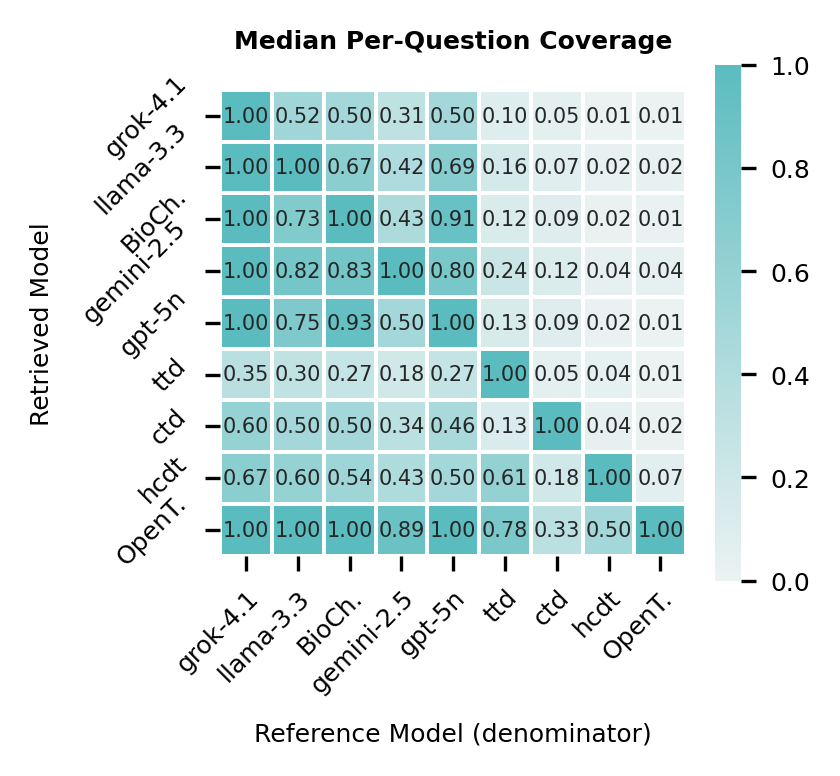

Plot saved as coverage_heatmap_70x70_00BCD4_fixed.pdf


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

models = list(dct_result.keys())
median_cov = pd.DataFrame(np.nan, index=models, columns=models)
n_common_q = pd.DataFrame(0, index=models, columns=models)

def unwrap_question_runs(obj, model_name):
    if not isinstance(obj, dict):
        return {}
    if model_name in obj and isinstance(obj[model_name], dict):
        return obj[model_name]                 # {model: {question: runs}}
    if len(obj) == 1 and isinstance(next(iter(obj.values())), dict):
        return next(iter(obj.values()))        # generic single-wrapper
    return obj                                 # already {question: runs}

def get_clean_row_set(df):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return set()

    id_cols = [c for c in df.columns if "id" in c.lower()]
    use_df = df[id_cols] if id_cols else df
    use_df = use_df.reindex(sorted(use_df.columns), axis=1)

    return {
        tuple(str(v).strip().lower() if pd.notna(v) else "nan" for v in row)
        for row in use_df.itertuples(index=False, name=None)
    }

# 1) Build per-model, per-question union across runs
row_unions = {m: {} for m in models}
for m in models:
    q_runs = unwrap_question_runs(dct_result[m], m)
    # print(f"Model: {m}, Questions found: {q_runs}")
    for q, runs in q_runs.items():
        if not isinstance(runs, dict):
            continue
        sets = []
        for _, payload in runs.items():
            if not isinstance(payload, dict):
                continue
            s = get_clean_row_set(payload.get("dataframe_id"))
            if s:
                sets.append(s)
        if sets:
            row_unions[m][q] = set.union(*sets)

# 2) Per-question directional score, then median across questions
for ref_model in models:
    for ret_model in models:
        common_queries = set(row_unions[ref_model]).intersection(row_unions[ret_model])

        scores = []
        for q in common_queries:
            ref_set = row_unions[ref_model][q]
            ret_set = row_unions[ret_model][q]
            if len(ref_set) == 0:
                continue
            scores.append(len(ref_set & ret_set) / len(ref_set))

        n_common_q.loc[ret_model, ref_model] = len(scores)
        median_cov.loc[ret_model, ref_model] = np.median(scores) if scores else np.nan

# # 3) Plot


import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1. Shorten Model Names
# =============================================================================
name_mapping = {
    "grok-4-1-fast-non-reasoning-latest": "grok-4.1",
    "llama-3.3-70b-versatile": "llama-3.3",
    "gemini-2.5-flash-lite": "gemini-2.5",
    "gpt-5-nano": "gpt-5n",
    "OpenTargets": "OpenT.",
    "BioChatter": "BioCh.",
    "ctd": "ctd", 
    "ttd": "ttd", 
    "hcdt": "hcdt"
}

# Apply the short names to both the rows (index) and the columns
median_cov = median_cov.rename(index=name_mapping, columns=name_mapping)

# =============================================================================
# 2. Apply Fixed Model Order (from your reference image)
# =============================================================================
desired_order = [
    "grok-4.1",
    "llama-3.3",
    "BioCh.",
    "gemini-2.5",
    "gpt-5n",
    "ttd",
    "ctd",
    "hcdt",
    "OpenT."
]

# Lock the DataFrame into this exact order on both axes
median_cov = median_cov.reindex(index=desired_order, columns=desired_order)

# =============================================================================
# 3. Plotting Configuration (70x70mm, Editable Vector PDF)
# =============================================================================
# Force True vector text for PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Set font globally to Arial, 6pt
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['font.size'] = 6
mpl.rcParams['axes.titlesize'] = 6
mpl.rcParams['axes.labelsize'] = 6
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6

# Convert mm to inches for Matplotlib
mm_to_in = 1 / 25.4
fig_size = 70 * mm_to_in

# Define figure size 70x70 mm
plt.figure(figsize=(fig_size, fig_size), dpi=300)

# =============================================================================
# 4. Custom Cyan Hex Colormap
# =============================================================================
# Creates a gradient from white to #00BCD4
cyan_cmap = sns.light_palette("#5BBCBF", as_cmap=True)

# Create the heatmap
ax = sns.heatmap(
    median_cov,
    annot=True,
    fmt=".2f",
    cmap=cyan_cmap,          # <--- Custom Hex Gradient applied here
    vmin=0,
    vmax=1,
    linewidths=0.5,          
    linecolor='white',
    square=True,             
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8} 
)

# Apply Titles and Labels
plt.title("Median Per-Question Coverage", pad=10, fontweight="bold")
plt.xlabel("Reference Model (denominator)", labelpad=6)
plt.ylabel("Retrieved Model", labelpad=6)

# Rotate X-axis tick labels 45 degrees and align to the right
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

# Rotate Y-axis tick labels 45 degrees
plt.yticks(rotation=45)

# Use tight_layout so nothing gets clipped
plt.tight_layout()

# Save the figure as a true vector PDF
plt.savefig(
    "coverage_heatmap_70x70_00BCD4_fixed.pdf", 
    format='pdf', 
    bbox_inches='tight', 
    transparent=True
)

plt.show()
print("Plot saved as coverage_heatmap_70x70_00BCD4_fixed.pdf")


## Panel r: Pairwise Similarity Heatmap (Publication Style)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

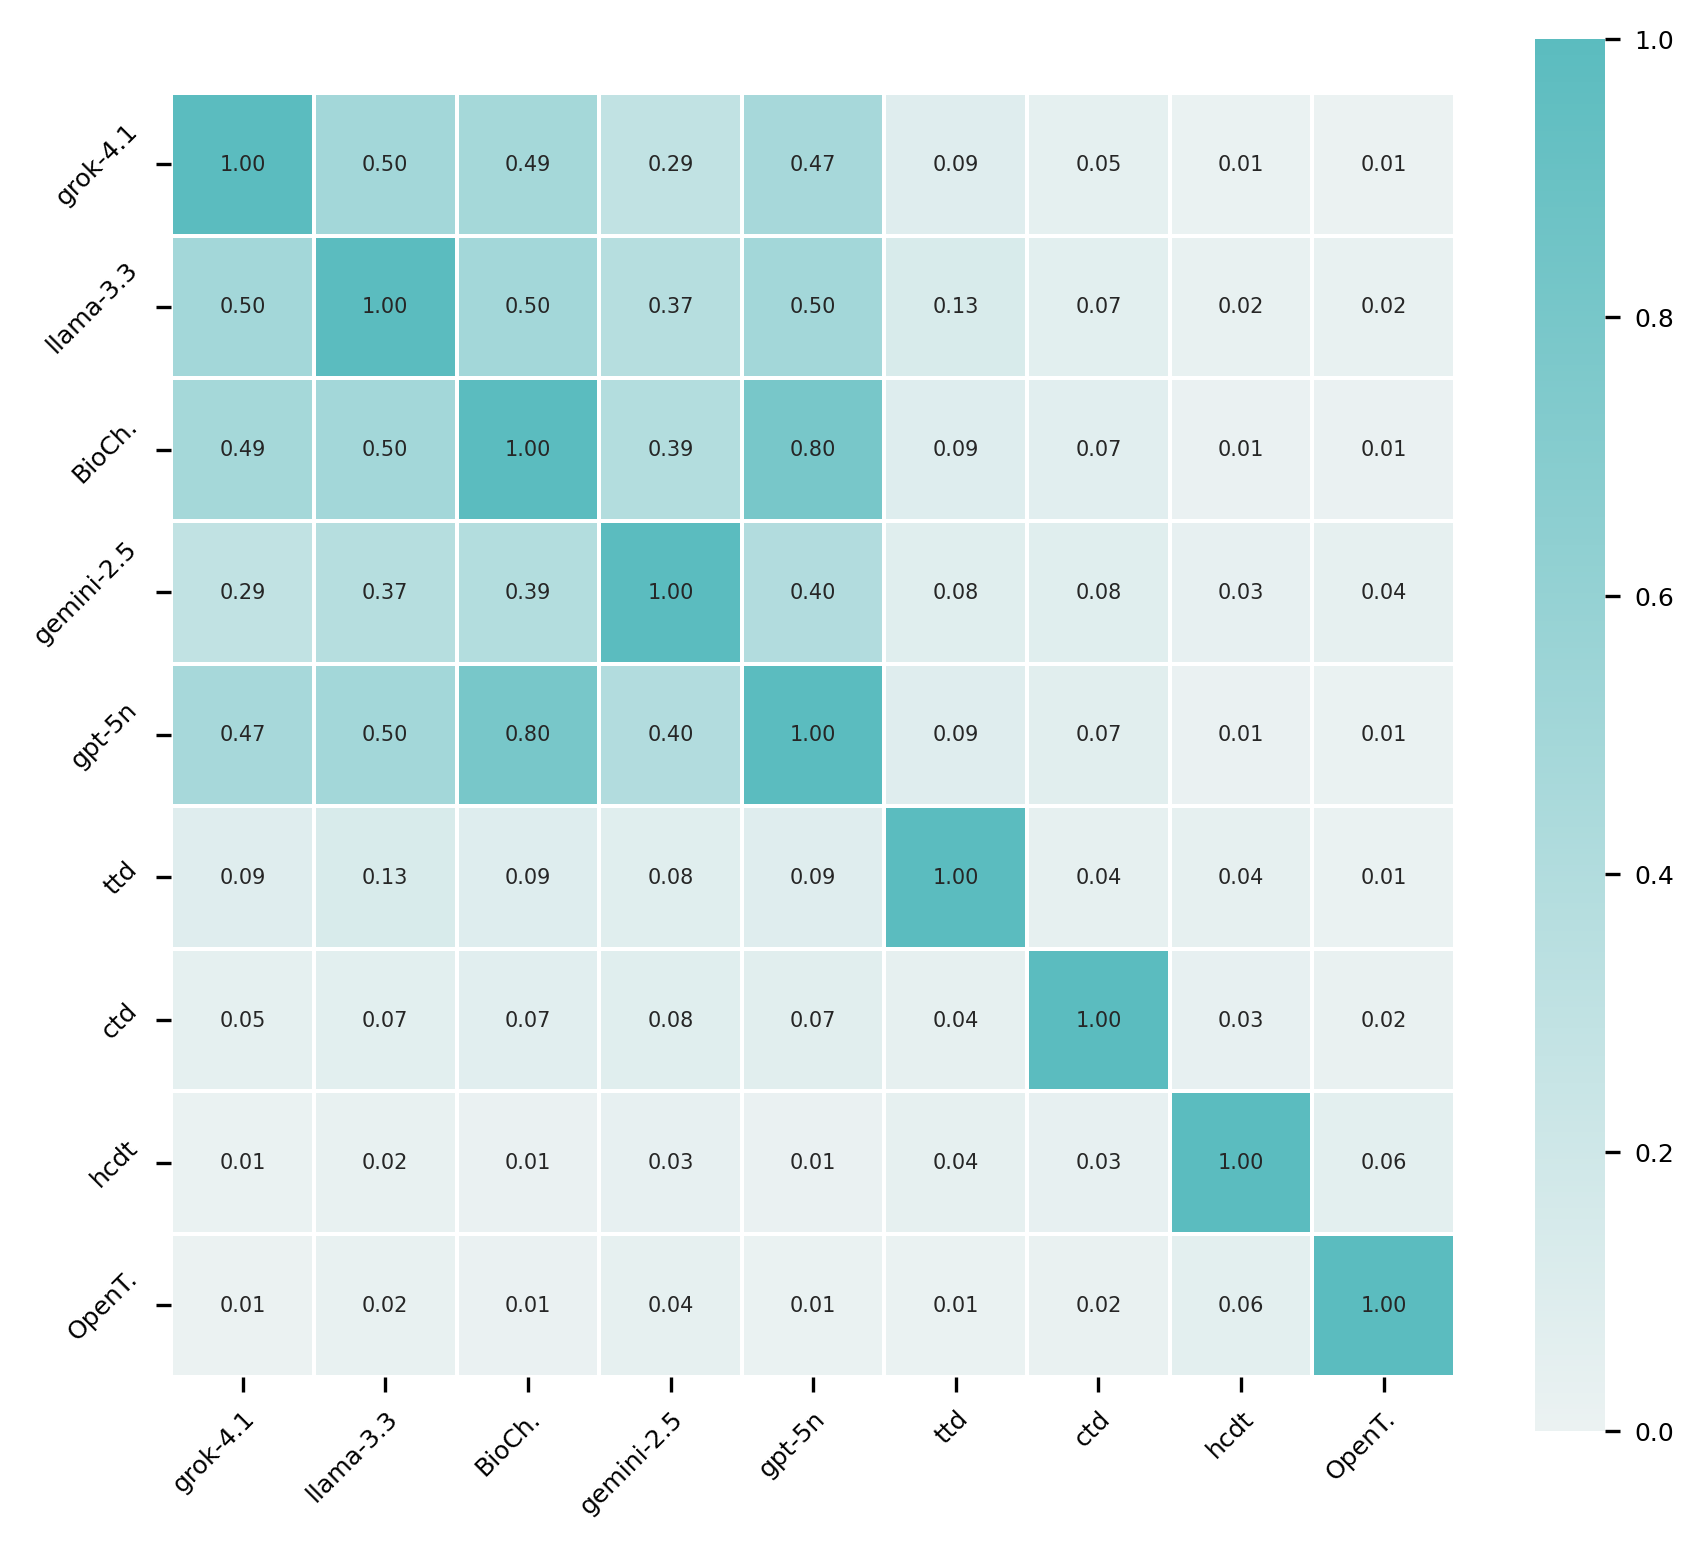

Plot saved as jaccard_heatmap_70x70_5BBCBF_short.pdf


In [14]:
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt



# =============================================================================
# 2.5 Shorten Model Names & Lock Order
# =============================================================================
name_mapping = {
    "grok-4-1-fast-non-reasoning-latest": "grok-4.1",
    "llama-3.3-70b-versatile": "llama-3.3",
    "gemini-2.5-flash-lite": "gemini-2.5",
    "gpt-5-nano": "gpt-5n",
    "OpenTargets": "OpenT.",
    "BioChatter": "BioCh.",
    "ctd": "ctd", 
    "ttd": "ttd", 
    "hcdt": "hcdt"
}




import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

models = list(dct_result.keys())
median_cov = pd.DataFrame(np.nan, index=models, columns=models)
n_common_q = pd.DataFrame(0, index=models, columns=models)

def unwrap_question_runs(obj, model_name):
    if not isinstance(obj, dict):
        return {}
    if model_name in obj and isinstance(obj[model_name], dict):
        return obj[model_name]                 # {model: {question: runs}}
    if len(obj) == 1 and isinstance(next(iter(obj.values())), dict):
        return next(iter(obj.values()))        # generic single-wrapper
    return obj                                 # already {question: runs}

def get_clean_row_set(df):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return set()

    id_cols = [c for c in df.columns if "id" in c.lower()]
    use_df = df[id_cols] if id_cols else df
    use_df = use_df.reindex(sorted(use_df.columns), axis=1)

    return {
        tuple(str(v).strip().lower() if pd.notna(v) else "nan" for v in row)
        for row in use_df.itertuples(index=False, name=None)
    }

# 1) Build per-model, per-question union across runs
row_unions = {m: {} for m in models}
for m in models:
    q_runs = unwrap_question_runs(dct_result[m], m)
    # print(f"Model: {m}, Questions found: {q_runs}")
    for q, runs in q_runs.items():
        if not isinstance(runs, dict):
            continue
        sets = []
        for _, payload in runs.items():
            if not isinstance(payload, dict):
                continue
            s = get_clean_row_set(payload.get("dataframe_id"))
            if s:
                sets.append(s)
        if sets:
            row_unions[m][q] = set.union(*sets)

# 2) Per-question directional score, then median across questions
for ref_model in models:
    for ret_model in models:
        common_queries = set(row_unions[ref_model]).intersection(row_unions[ret_model])

        scores = []
        for q in common_queries:
            ref_set = row_unions[ref_model][q]
            ret_set = row_unions[ret_model][q]
            if len(ref_set) == 0:
                continue
            scores.append(len(ref_set & ret_set) / len(ref_set | ret_set))

        n_common_q.loc[ret_model, ref_model] = len(scores)
        median_cov.loc[ret_model, ref_model] = np.median(scores) if scores else np.nan


# Apply the short names to both the rows (index) and the columns
median_cov = median_cov.rename(index=name_mapping, columns=name_mapping)

# =============================================================================
# 2. Apply Fixed Model Order (from your reference image)
# =============================================================================
desired_order = [
    "grok-4.1",
    "llama-3.3",
    "BioCh.",
    "gemini-2.5",
    "gpt-5n",
    "ttd",
    "ctd",
    "hcdt",
    "OpenT."
]

# Lock the DataFrame into this exact order on both axes
median_cov = median_cov.reindex(index=desired_order, columns=desired_order)

# =============================================================================
# 3. Plotting Configuration (70x70mm, Editable Vector PDF)
# =============================================================================
# Force True vector text for PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Set font globally to Arial, 6pt
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['font.size'] = 6
mpl.rcParams['axes.titlesize'] = 6
mpl.rcParams['axes.labelsize'] = 6
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6

# Convert mm to inches for Matplotlib
mm_to_in = 1 / 25.4
fig_size = 70 * mm_to_in

# Define figure size 70x70 mm
plt.figure(figsize=(6, 6), dpi=300)

# =============================================================================
# 4. Custom Hex Colormap (#5BBCBF)
# =============================================================================
# Creates a gradient from white to your specified teal/cyan
cyan_cmap = sns.light_palette("#5BBCBF", as_cmap=True)

# Create the heatmap
ax = sns.heatmap(
    median_cov,
    annot=True,
    fmt=".2f",
    cmap=cyan_cmap,          
    vmin=0,
    vmax=1,
    linewidths=0.5,          
    linecolor='white',
    square=True,             
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8} 
)

# Apply Titles and Labels
# Note: Since Jaccard is symmetric, the axes labels are updated slightly to reflect that
# plt.title("Median Per-Question Jaccard Similarity", pad=10, fontweight="bold")
# plt.xlabel("Model A", labelpad=6)
# plt.ylabel("Model B", labelpad=6)

# Rotate X-axis tick labels 45 degrees and align to the right
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

# Rotate Y-axis tick labels 45 degrees
plt.yticks(rotation=45)

# Use tight_layout so nothing gets clipped
plt.tight_layout()

# Save the figure as a true vector PDF
plt.savefig(
    "jaccard_heatmap_70x70_5BBCBF_short.pdf", 
    format='pdf', 
    bbox_inches='tight', 
    transparent=True
)

plt.show()
print("Plot saved as jaccard_heatmap_70x70_5BBCBF_short.pdf")

Arial not found. Falling back to DejaVu Sans.
Rows after filtering: 1277
Models present: ['ttd', 'ctd', 'hcdt', 'OpenTargets']


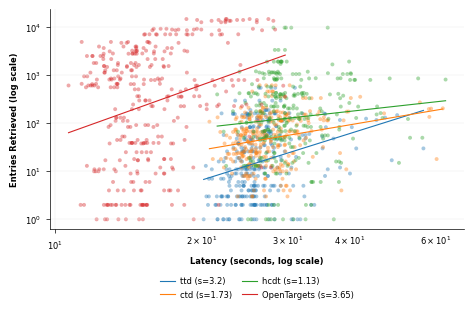


Per-model log-log regression summary:
      model  slope_loglog  intercept_log10  rvalue  pvalue   n
        ttd        3.1997          -3.3432  0.2923  0.0000 324
        ctd        1.7320          -0.8086  0.2443  0.0000 309
       hcdt        1.1306           0.4360  0.0993  0.0886 295
OpenTargets        3.6488          -1.9473  0.2801  0.0000 349

Saved plot to:
- regression_latency_vs_rows_120x80.pdf
- regression_latency_vs_rows_120x80.svg


In [26]:
# =============================================================================
# Premium Regression Plot | 120 x 80 mm
# x = Latency, y = Rows Retrieved | Log-Log Linear Regression
# Models: ttd, ctd, hcdt, OpenTargets
# Style: Pure Black Axes, Arial 6pt, Bottom Legend. Editable Vectors (PDF/SVG)
# Exports slope of each fitted line in the legend
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from scipy.stats import linregress
import matplotlib.font_manager as fm

# ── 0. Global plotting settings ──────────────────────────────────────────────
# Use Arial if available; otherwise fall back safely
available_fonts = {f.name for f in fm.fontManager.ttflist}
if "Arial" in available_fonts:
    plt.rcParams["font.family"] = "Arial"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
    print("Arial not found. Falling back to DejaVu Sans.")

plt.rcParams["pdf.fonttype"] = 42      # editable text in PDF
plt.rcParams["svg.fonttype"] = "none"  # editable text in SVG

# ── 1. Load Data ─────────────────────────────────────────────────────────────
df = pd.read_csv("ridgeline_data.csv")

# ── 2. Filter for Specific Models and Clean Data ─────────────────────────────
target_models = ["ttd", "ctd", "hcdt", "OpenTargets", "OpenTarget"]

df_filtered = (
    df.loc[
        df["rows"].notna()
        & df["latency"].notna()
        & np.isfinite(df["rows"])
        & np.isfinite(df["latency"])
        & (df["rows"] > 0)
        & (df["latency"] > 0)
        & (df["model"].isin(target_models))
    ]
    .copy()
)

# Consolidate naming
df_filtered["model"] = df_filtered["model"].replace({"OpenTarget": "OpenTargets"})

# Fixed order
model_order = ["ttd", "ctd", "hcdt", "OpenTargets"]
df_filtered["model"] = pd.Categorical(
    df_filtered["model"],
    categories=model_order,
    ordered=True
)
df_filtered = df_filtered.sort_values("model")

# Optional sanity check
print("Rows after filtering:", len(df_filtered))
print("Models present:", df_filtered["model"].dropna().unique().tolist())

# ── 3. Color Palette ─────────────────────────────────────────────────────────
model_colors = {
    "ttd": "#1f77b4",         # Blue
    "ctd": "#ff7f0e",         # Orange
    "hcdt": "#2ca02c",        # Green
    "OpenTargets": "#d62728"  # Red
}

# ── 4. Figure Setup ──────────────────────────────────────────────────────────
mm_to_inch = 1 / 25.4
fig, ax = plt.subplots(figsize=(120 * mm_to_inch, 80 * mm_to_inch))

# ── 5. Plot Points + Log-Log Regression per Model ───────────────────────────
slope_summary = []

for model in model_order:
    sub = df_filtered[df_filtered["model"] == model].copy()
    if sub.empty:
        continue

    x = sub["latency"].to_numpy(dtype=float)
    y = sub["rows"].to_numpy(dtype=float)
    color = model_colors[model]

    # Scatter points
    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.4,
        color=color,
        edgecolors="none"
    )

    # Regression in log-log space
    logx = np.log10(x)
    logy = np.log10(y)
    fit = linregress(logx, logy)

    # Smooth fitted line over observed x-range
    x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    y_line = 10 ** (fit.intercept + fit.slope * np.log10(x_line))

    # Legend label includes slope
    label = f"{model} (s={fit.slope:.3g})"

    ax.plot(
        x_line,
        y_line,
        color=color,
        linewidth=0.8,
        label=label
    )

    slope_summary.append({
        "model": model,
        "slope_loglog": fit.slope,
        "intercept_log10": fit.intercept,
        "rvalue": fit.rvalue,
        "pvalue": fit.pvalue,
        "n": len(sub)
    })

# ── 6. Log Scales ────────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

# ── 7. Labels ────────────────────────────────────────────────────────────────
ax.set_xlabel("Latency (seconds, log scale)", fontsize=6, fontweight="bold", color="black")
ax.set_ylabel("Entries Retrieved (log scale)", fontsize=6, fontweight="bold", color="black")

# ── 8. Theme Styling ─────────────────────────────────────────────────────────
ax.grid(True, which="major", color="#E5E5E5", linewidth=0.25)
ax.grid(False, which="minor")

# Pure black axes
for spine in ["bottom", "left"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("black")
    ax.spines[spine].set_linewidth(0.5)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="both", which="major", colors="black", labelsize=6, width=0.5, length=3)
ax.tick_params(axis="both", which="minor", length=0)

# Legend at bottom
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    fontsize=6,
    title=None,
    handlelength=1.8,
    handletextpad=0.6,
    columnspacing=1.2
)

plt.tight_layout()

# ── 9. Export ────────────────────────────────────────────────────────────────
pdf_path = "regression_latency_vs_rows_120x80.pdf"
svg_path = "regression_latency_vs_rows_120x80.svg"

plt.savefig(pdf_path, bbox_inches="tight", transparent=False)
plt.savefig(svg_path, bbox_inches="tight", transparent=False)

plt.show()

# ── 10. Print slope table ────────────────────────────────────────────────────
slope_df = pd.DataFrame(slope_summary)
print("\nPer-model log-log regression summary:")
print(slope_df.round(4).to_string(index=False))

print(f"\nSaved plot to:\n- {pdf_path}\n- {svg_path}")